In [2]:
import torch
import torch.nn as nn

#there are some logical building blocks
# 1. doubleconv2D : [conv2D -> batchNorm -> RELU] *2 
# 2. Downsample

class doubleConv2D(nn.Module):
    def __init__(self,input_ch, output_ch):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels=input_ch,out_channels=output_ch,kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=output_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=output_ch,out_channels=output_ch,kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=output_ch),
            nn.ReLU(inplace=True),
        )
    
    def forward(self,x):
        return self.double_conv(x)
    

class DownSample(nn.Module):
    def __init__(self,input_channels, output_channels,kernel_size=2,stride=2):
        super().__init__()
        
        self.downsample = nn.Sequential(
            nn.MaxPool2d(kernel_size=kernel_size,stride=stride),
            doubleConv2D(input_ch=input_channels,output_ch=output_channels)
        )
    
    def forward(self,x):
        return self.downsample(x)
    


class UNET_encoder(nn.Module):
    def __init__(self, **params):
        super().__init__()

        self.first_double_conv = doubleConv2D(1,64)
        self.downsample1 = DownSample(64,128)
        self.downsample2 = DownSample(128,256)
        self.downsample3 = DownSample(256,512)
        self.downsample4 = DownSample(512,1024)


    def forward(self,x):

        f1 = self.first_double_conv(x)
        f2 = self.downsample1(f1)
        f3 = self.downsample2(f2)
        f4 = self.downsample3(f3)
        bottleneck = self.downsample4(f4)

        return bottleneck, [f4, f3 ,f2,f1]
    

class UNET_decoder(nn.Module):
    def __init__(self, **params):
        super().__init__()

        self.tcv1 = nn.ConvTranspose2d(in_channels=1024,out_channels=512,kernel_size=2,stride=2)
        self.double_conv1 = doubleConv2D(input_ch=1024,output_ch=512) #after concatinating the skip connection, the channels will
        #be equal to 1024

        self.tcv2 = nn.ConvTranspose2d(in_channels=512,out_channels=256,kernel_size=2,stride=2)
        self.double_conv2 = doubleConv2D(input_ch=512,output_ch=256)

        self.tcv3 = nn.ConvTranspose2d(in_channels=256,out_channels=128,kernel_size=2,stride=2)
        self.double_conv3 = doubleConv2D(input_ch=256,output_ch=128)

        self.tcv4 = nn.ConvTranspose2d(in_channels=128,out_channels=64,kernel_size=2,stride=2)
        self.double_conv4 = doubleConv2D(input_ch=128,output_ch=64)


    def forward(self,bottleneck,skip_conns_list):

        upsample_1 = self.tcv1(bottleneck)
        #now we need to concat with the skip connection
        concat_skip_1 = torch.concat([upsample_1,skip_conns_list[0]],dim=1)
        double_conv1_op = self.double_conv1(concat_skip_1)

        upsample_2 = self.tcv2(double_conv1_op)
        concat_skip_2 = torch.concat([upsample_2,skip_conns_list[1]],dim=1)
        double_conv2_op = self.double_conv2(concat_skip_2)

        upsample_3 = self.tcv3(double_conv2_op)
        concat_skip_3 = torch.concat([upsample_3,skip_conns_list[2]],dim=1)
        double_conv3_op = self.double_conv3(concat_skip_3)

        upsample_4 = self.tcv4(double_conv3_op)
        concat_skip_4 = torch.concat([upsample_4,skip_conns_list[3]],dim=1)
        double_conv4_op = self.double_conv4(concat_skip_4)

        return double_conv4_op
    


class UNET_final(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = UNET_encoder()
        self.decoder = UNET_decoder()
        self.one_Cross_one_conv = nn.Conv2d(in_channels=64,out_channels=1,kernel_size=1,stride=1)

    def forward(self,x):
        bottleneck, skip_conns_list = self.encoder(x)
        final_conv_op = self.decoder(bottleneck,skip_conns_list)
        final_image = self.one_Cross_one_conv(final_conv_op)

        return final_image




# training Script

In [3]:
# !pip install torchmetrics
import updated_dataloader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm  # Provides a nice progress bar
from fastmri.data.subsample import EquiSpacedMaskFunc
import glob
import os
from torchmetrics import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

/home/biswamitra/health/yash/miniconda3/envs/biswa_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# test first model performance

Loading model from: /home/biswamitra/health/knee_data/EDA/saved_model/unet_mri_model_latest.pth
Running inference...
Batch Evaluation Results -> PSNR: 19.65 dB | SSIM: 0.8995


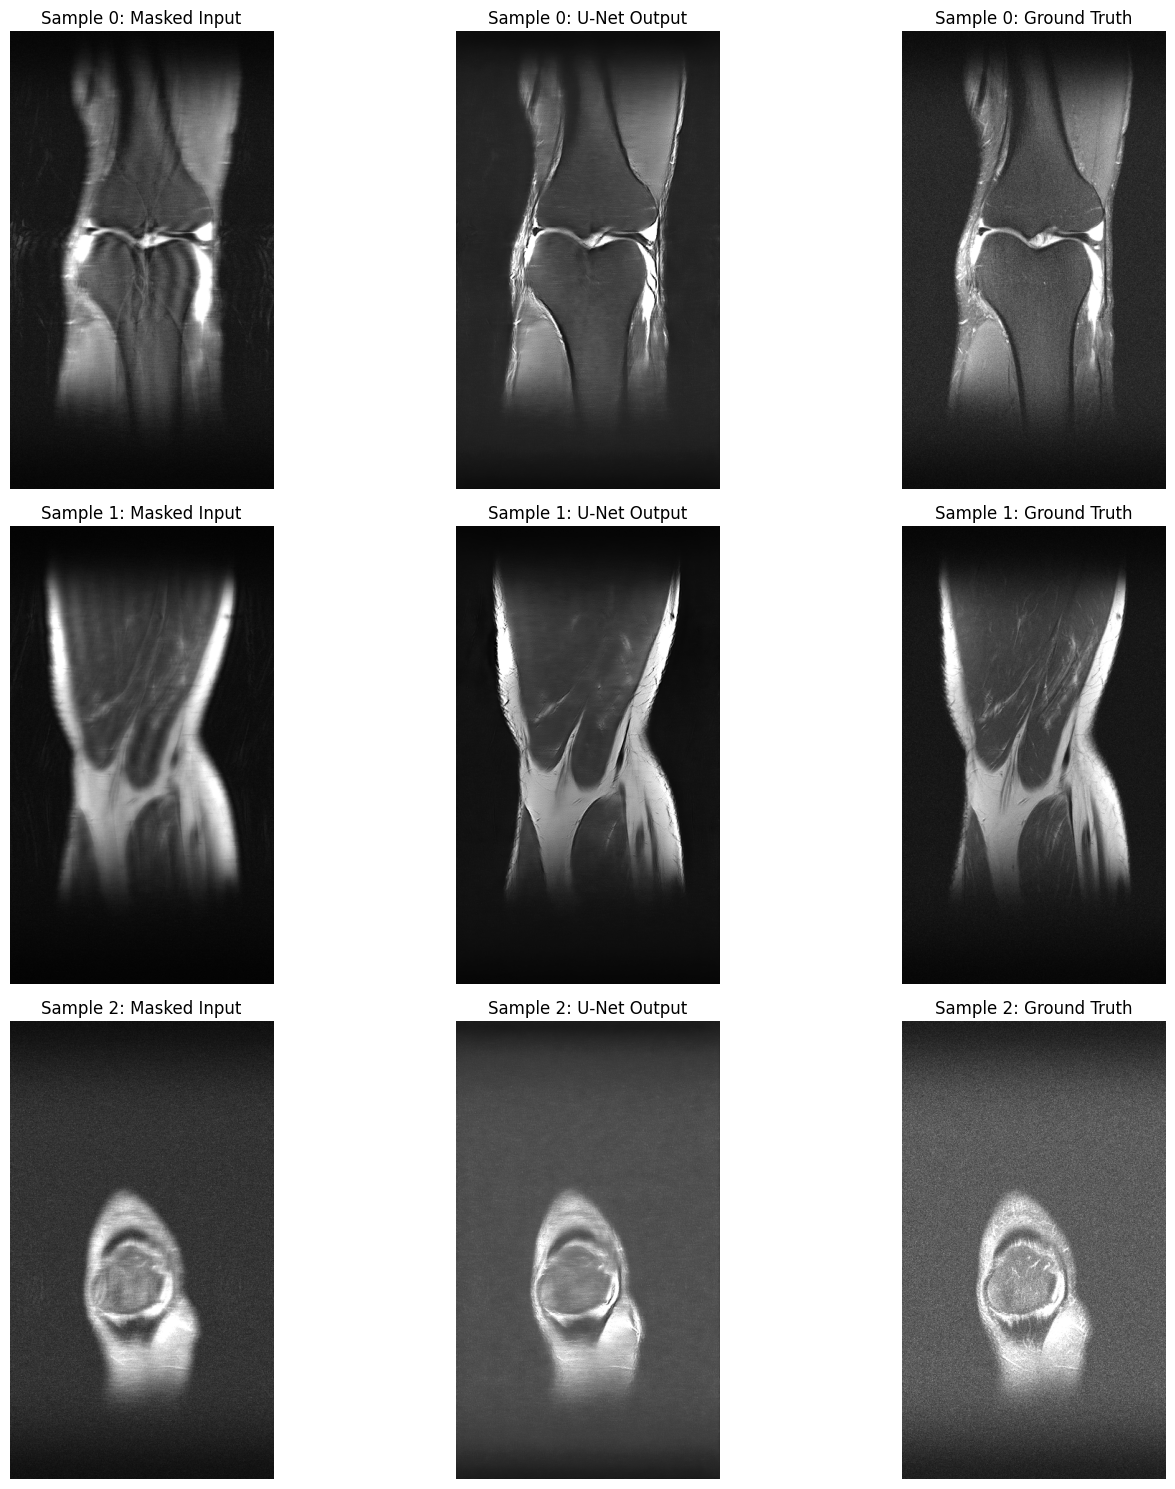

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
from torch.utils.data import DataLoader
from torchmetrics import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

# --- IMPORT YOUR CUSTOM MODULES HERE ---
# e.g., import updated_dataloader
# from your_model_file import UNET_final

# ==========================================
# 1. SETUP & LOAD MODEL
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
saved_model_path = "/home/biswamitra/health/knee_data/EDA/saved_model/unet_mri_model_latest.pth"
data_dir = "/home/biswamitra/health/knee_data/val/deconstructed_val/"

print(f"Loading model from: {saved_model_path}")

# Initialize the model and load the trained weights
model = UNET_final().to(device)
model.load_state_dict(torch.load(saved_model_path, map_location=device))

# CRITICAL: Set to evaluation mode! 
# This ensures layers like BatchNorm use learned statistics rather than the current batch's statistics.
model.eval()

# Set up metrics (data_range is 1.0 because we will normalize the tensors below)
psnr_module = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_module = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# ==========================================
# 2. LOAD A TEST BATCH
# ==========================================
file_list = sorted(glob.glob(data_dir + "*.npy"))

# Initialize dataset (using the same settings as training)
test_data = updated_dataloader.Custom_FMRI_DataLoader_nil(
    data_paths=file_list,
    mask_func=EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[4]),
    input_req=[1,1,1,1,1],
    output_req=[1,1,1,1],
    methods_flags=[0,0]
)

# Batch size of 3 is perfect for a clean 3-row Matplotlib figure
test_loader = DataLoader(test_data, batch_size=3, shuffle=True)
batch = next(iter(test_loader))

# Extract, add channel dim, and cast to float32
inputs = batch['masked_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)
targets = batch['full_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)

# --- DYNAMIC BATCH NORMALIZATION ---
# Apply the exact same scaling you used in training
batch_max = targets.max()
if batch_max > 0:
    inputs = inputs / batch_max
    targets = targets / batch_max

# ==========================================
# 3. RUN INFERENCE & CALCULATE METRICS
# ==========================================
print("Running inference...")

# torch.no_grad() speeds up computation and prevents out-of-memory errors during testing
with torch.no_grad():
    predictions = model(inputs)
    
    # Calculate quantitative metrics for this batch
    batch_psnr = psnr_module(predictions, targets).item()
    batch_ssim = ssim_module(predictions, targets).item()

print(f"Batch Evaluation Results -> PSNR: {batch_psnr:.2f} dB | SSIM: {batch_ssim:.4f}")

# ==========================================
# 4. VISUALIZATION
# ==========================================
# Move tensors to CPU, remove the channel dimension, and convert to NumPy arrays for plotting
inputs_np = inputs.squeeze(1).cpu().numpy()
targets_np = targets.squeeze(1).cpu().numpy()
preds_np = predictions.squeeze(1).cpu().numpy()

num_images = inputs_np.shape[0]
fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))

for i in range(num_images):
    # Calculate the 99th percentile of the Ground Truth to clip extreme bright outliers
    # We use the target's vmax across all three columns for a fair visual comparison
    vmax = np.percentile(targets_np[i], 99)

    # Column 1: Masked Input (The aliased image)
    axes[i, 0].imshow(inputs_np[i], cmap='gray', vmin=0, vmax=vmax)
    axes[i, 0].set_title(f"Sample {i}: Masked Input")
    axes[i, 0].axis('off')
    
    # Column 2: U-Net Prediction (The denoised image)
    axes[i, 1].imshow(preds_np[i], cmap='gray', vmin=0, vmax=vmax)
    axes[i, 1].set_title(f"Sample {i}: U-Net Output")
    axes[i, 1].axis('off')
    
    # Column 3: Ground Truth (The target image)
    axes[i, 2].imshow(targets_np[i], cmap='gray', vmin=0, vmax=vmax)
    axes[i, 2].set_title(f"Sample {i}: Ground Truth")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# checking model details

In [18]:
from torchinfo import summary

summary(model, input_size=(1, 1, 640, 368))

Layer (type:depth-idx)                             Output Shape              Param #
UNET_final                                         [1, 1, 640, 368]          --
├─UNET_encoder: 1-1                                [1, 1024, 40, 23]         --
│    └─doubleConv2D: 2-1                           [1, 64, 640, 368]         --
│    │    └─Sequential: 3-1                        [1, 64, 640, 368]         37,824
│    └─DownSample: 2-2                             [1, 128, 320, 184]        --
│    │    └─Sequential: 3-2                        [1, 128, 320, 184]        221,952
│    └─DownSample: 2-3                             [1, 256, 160, 92]         --
│    │    └─Sequential: 3-3                        [1, 256, 160, 92]         886,272
│    └─DownSample: 2-4                             [1, 512, 80, 46]          --
│    │    └─Sequential: 3-4                        [1, 512, 80, 46]          3,542,016
│    └─DownSample: 2-5                             [1, 1024, 40, 23]         --
│    │    └─Se

# multi GPU training code

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import glob
from fastmri.data.subsample import EquiSpacedMaskFunc
from torchmetrics import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

# ==========================================
# 1. SETUP & HYPERPARAMETERS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 50 
batch_size = 24  # Increased for dual-GPU
learning_rate = 2e-4  # Scaled up for larger batch size
patience = 5  # For early stopping

train_dir = "/home/biswamitra/health/knee_data/train/deconstructed_train/"
val_dir = "/home/biswamitra/health/knee_data/val/deconstructed_val/"
saved_model_path = "/home/biswamitra/health/knee_data/EDA/saved_model/unet_mri_model.pth"

# ==========================================
# 2. DATALOADERS
# ==========================================
train_files = sorted(glob.glob(train_dir + "*.npy"))
val_files = sorted(glob.glob(val_dir + "*.npy"))

print(f"Found {len(train_files)} training files and {len(val_files)} validation files.")

mask_func = EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20])

train_data = updated_dataloader.Custom_FMRI_DataLoader_nil(
    data_paths=train_files, mask_func=mask_func,
    input_req=[1,1,1,1,1], output_req=[1,1,1,1], methods_flags=[0,0]
)

val_data = updated_dataloader.Custom_FMRI_DataLoader_nil(
    data_paths=val_files, mask_func=mask_func,
    input_req=[1,1,1,1,1], output_req=[1,1,1,1], methods_flags=[0,0]
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# ==========================================
# 3. MODEL, LOSS, & OPTIMIZER
# ==========================================
model = UNET_final()

# Multi-GPU Setup
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via nn.DataParallel!")
    model = nn.DataParallel(model)

model = model.to(device)

class SpecialLossFunc(nn.Module):
    def __init__(self, alpha=0.86):
        super().__init__()
        self.alpha = alpha
        self.l1_loss = nn.L1Loss()
        self.ssim = StructuralSimilarityIndexMeasure(data_range=1.0) 

    def forward(self, preds, targets):
        l1_loss = self.l1_loss(preds, targets)
        ssim_val = self.ssim(preds, targets)
        ssim_loss = 1.0 - ssim_val
        hybrid_loss = (1.0 - self.alpha) * l1_loss + self.alpha * ssim_loss
        return hybrid_loss
    
loss_func = SpecialLossFunc().to(device)
psnr_module = PeakSignalNoiseRatio(data_range=1.0).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ==========================================
# 4. TRAINING & VALIDATION LOOP
# ==========================================
trigger_times = 0
best_val_loss = float('inf')

for epoch in range(num_epochs):
    
    # --- TRAINING PHASE ---
    model.train() 
    running_train_loss = 0.0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]") 
    
    for batch in train_loop:
        input_tensor = batch['masked_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)
        target_tensor = batch['full_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)

        # Dynamic Normalization
        batch_max = target_tensor.max()
        if batch_max > 0:
            input_tensor = input_tensor / batch_max
            target_tensor = target_tensor / batch_max

        optimizer.zero_grad()
        
        predictions = model(input_tensor)
        loss = loss_func(predictions, target_tensor)
        
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = running_train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    running_val_psnr = 0.0

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        
        for batch in val_loop:
            input_tensor = batch['masked_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)
            target_tensor = batch['full_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)

            # Dynamic Normalization
            batch_max = target_tensor.max()
            if batch_max > 0:
                input_tensor = input_tensor / batch_max
                target_tensor = target_tensor / batch_max

            predictions = model(input_tensor)
            val_loss = loss_func(predictions, target_tensor)
            running_val_loss += val_loss.item()
            
            psnr_val = psnr_module(predictions, target_tensor)
            running_val_psnr += psnr_val.item()
            
            val_loop.set_postfix(val_loss=val_loss.item(), psnr=psnr_val.item())

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_psnr = running_val_psnr / len(val_loader)

    print(f"\nEpoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PSNR: {avg_val_psnr:.2f} dB")

    # --- EARLY STOPPING & SAVING ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_times = 0
        
        # Safe saving for Multi-GPU
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), saved_model_path)
        else:
            torch.save(model.state_dict(), saved_model_path)
            
        print(f"--> Best model saved! (Val Loss: {best_val_loss:.4f})\n")
    else:
        trigger_times += 1
        print(f"--> No improvement. Early stopping trigger: {trigger_times} / {patience}\n")
        
        if trigger_times >= patience:
            print(f"Early stopping triggered! Training halted at epoch {epoch+1}.")
            break

Loading model from: /home/biswamitra/health/knee_data/EDA/saved_model/data_parallel_unet_mri_model.pth
Running inference...
Batch Evaluation Results -> PSNR: 30.28 dB | SSIM: 0.8642


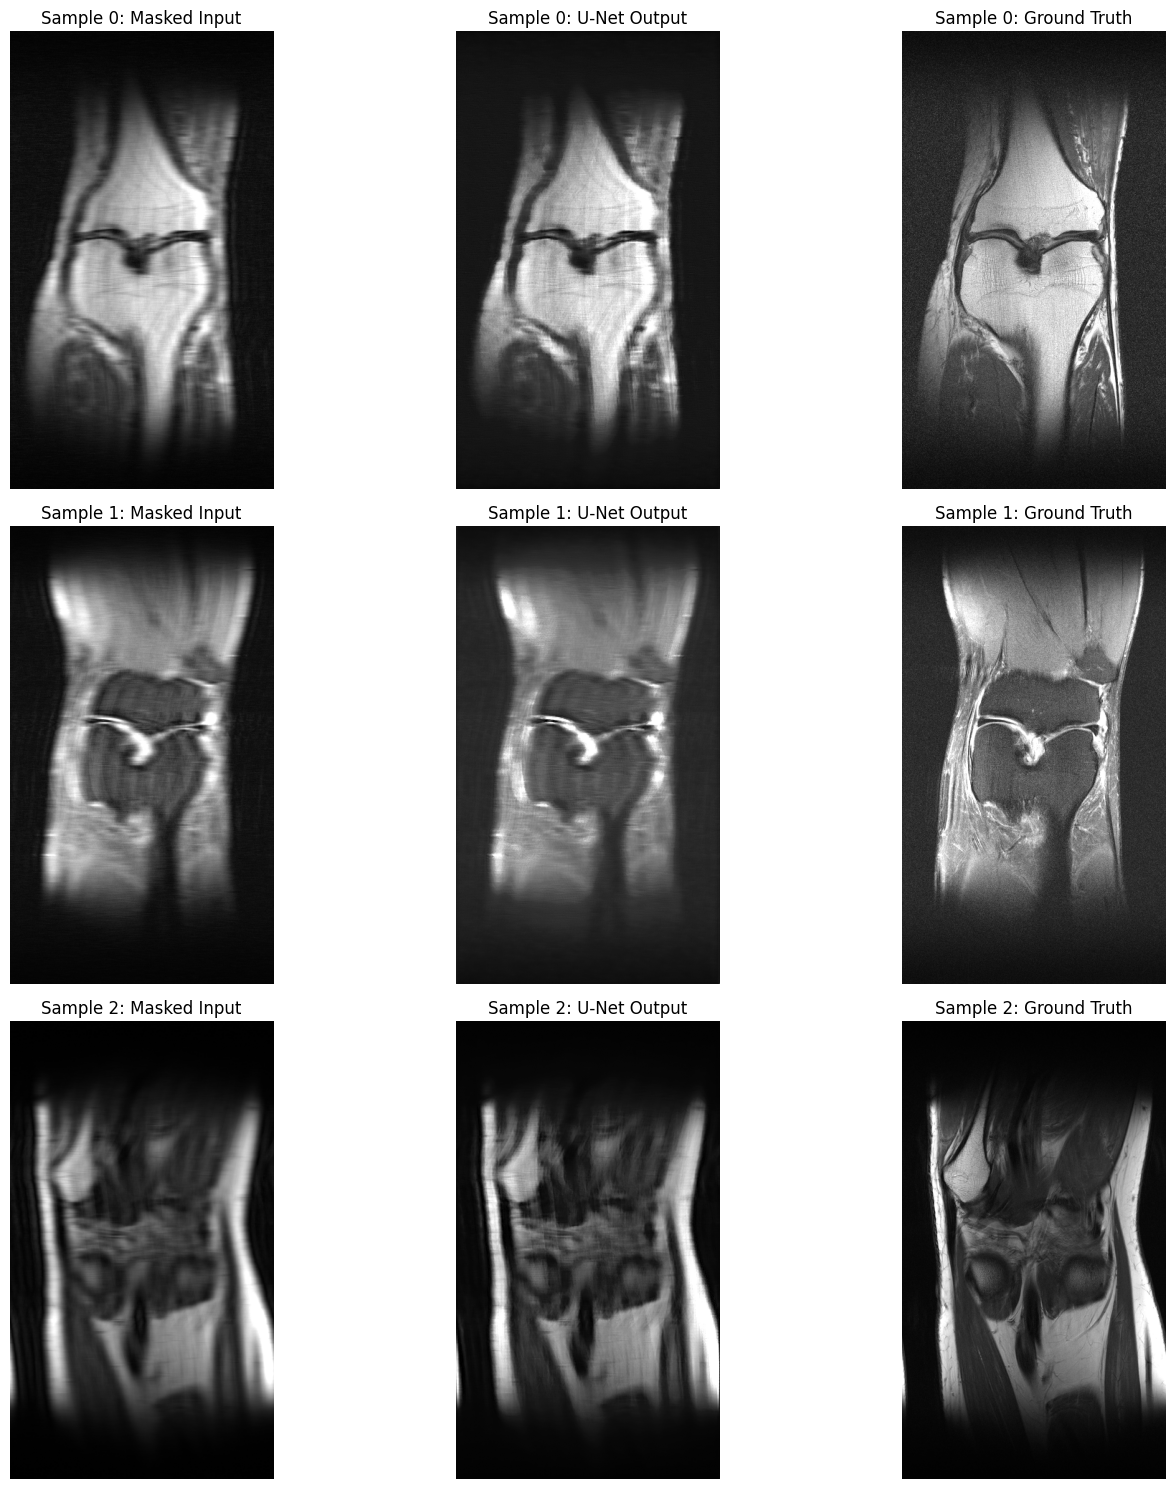

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
from torch.utils.data import DataLoader
from torchmetrics import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

# ==========================================
# 1. SETUP & LOAD MODEL
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
saved_model_path = "/home/biswamitra/health/knee_data/EDA/saved_model/data_parallel_unet_mri_model.pth"
data_dir = "/home/biswamitra/health/knee_data/val/deconstructed_val/"

print(f"Loading model from: {saved_model_path}")

# Initialize the model and load the trained weights
model = UNET_final().to(device)
model.load_state_dict(torch.load(saved_model_path, map_location=device))

model.eval()

# Set up metrics (data_range is 1.0 because we will normalize the tensors below)
psnr_module = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_module = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# ==========================================
# 2. LOAD A TEST BATCH
# ==========================================
file_list = sorted(glob.glob(data_dir + "*.npy"))

# Initialize dataset (using the same settings as training)
test_data = updated_dataloader.Custom_FMRI_DataLoader_nil(
    data_paths=file_list,
    mask_func=EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20]),
    input_req=[1,1,1,1,1],
    output_req=[1,1,1,1],
    methods_flags=[0,0]
)

# Batch size of 3 is perfect for a clean 3-row Matplotlib figure
test_loader = DataLoader(test_data, batch_size=3, shuffle=True)
batch = next(iter(test_loader))

# Extract, add channel dim, and cast to float32
inputs = batch['masked_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)
targets = batch['full_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)

# --- DYNAMIC BATCH NORMALIZATION ---
# Apply the exact same scaling you used in training
batch_max = targets.max()
if batch_max > 0:
    inputs = inputs / batch_max
    targets = targets / batch_max

# ==========================================
# 3. RUN INFERENCE & CALCULATE METRICS
# ==========================================
print("Running inference...")

# torch.no_grad() speeds up computation and prevents out-of-memory errors during testing
with torch.no_grad():
    predictions = model(inputs)
    
    # Calculate quantitative metrics for this batch
    batch_psnr = psnr_module(predictions, targets).item()
    batch_ssim = ssim_module(predictions, targets).item()

print(f"Batch Evaluation Results -> PSNR: {batch_psnr:.2f} dB | SSIM: {batch_ssim:.4f}")

# ==========================================
# 4. VISUALIZATION
# ==========================================
# Move tensors to CPU, remove the channel dimension, and convert to NumPy arrays for plotting
inputs_np = inputs.squeeze(1).cpu().numpy()
targets_np = targets.squeeze(1).cpu().numpy()
preds_np = predictions.squeeze(1).cpu().numpy()

num_images = inputs_np.shape[0]
fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))

for i in range(num_images):
    # Calculate the 99th percentile of the Ground Truth to clip extreme bright outliers
    # We use the target's vmax across all three columns for a fair visual comparison
    vmax = np.percentile(targets_np[i], 99)

    # Column 1: Masked Input (The aliased image)
    axes[i, 0].imshow(inputs_np[i], cmap='gray', vmin=0, vmax=vmax)
    axes[i, 0].set_title(f"Sample {i}: Masked Input")
    axes[i, 0].axis('off')
    
    # Column 2: U-Net Prediction (The denoised image)
    axes[i, 1].imshow(preds_np[i], cmap='gray', vmin=0, vmax=vmax)
    axes[i, 1].set_title(f"Sample {i}: U-Net Output")
    axes[i, 1].axis('off')
    
    # Column 3: Ground Truth (The target image)
    axes[i, 2].imshow(targets_np[i], cmap='gray', vmin=0, vmax=vmax)
    axes[i, 2].set_title(f"Sample {i}: Ground Truth")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()